# Figure 9 — Bulk RNA-seq + proteomics: SQ vs LQ feeders

Panels:

- **d**: Log2FC bar plot of selected proteomics DEPs (FDR < 0.05), SQ vs LQ
- **k**: Downregulated GO terms (BP) in SQ-FL — GeneRatio dotplot
- **l**: Upregulated GO terms (BP) in SQ-FL — GeneRatio dotplot

Inputs (preprocessed upstream):
- `regulation_table_permutation-2_EXP-SQvsLQ.csv` — full proteomics table
- `Significant_features_proteomicsSQvsLQ_permutation.csv` — significant DEPs (UP / DOWN columns)
- `DEGs_SQ_vs_LQ_with_symbols.csv` — bulk RNA-seq DEGs (DESeq2 output, padj<0.05 & |log2FC|>1.5)

**Structure**:
1. Imports / output dir
2. Section 0 — *(optional, gated by `RUN_BUILD`)* full DESeq2 pipeline that produces the
   DEG CSV. Default OFF — we assume the CSV already exists.
3. Section 1 — Load DEGs + proteomics CSVs
4. Section 2 — GO enrichment on up- / down-regulated DEGs (cheap, run every time)
5. Panel d (proteomics bar plot)
6. Panel k (downregulated GO dotplot)
7. Panel l (upregulated GO dotplot)

## Imports

In [1]:
suppressPackageStartupMessages({
    library(tidyverse)
    library(ggplot2)
    library(dplyr)
    library(stringr)
    library(forcats)
    library(clusterProfiler)
    library(org.Mm.eg.db)
})

# Output directory for the saved figure SVGs (matches convention used by figs 1, 3, 6, 7)
out_dir <- '../manuscript_figures/figure_9'
dir.create(out_dir, showWarnings = FALSE, recursive = TRUE)

Warning message:
“package ‘readr’ was built under R version 4.2.3”
Warning message:
“package ‘forcats’ was built under R version 4.2.3”


## Section 0 — Build DEG table from raw counts (run once, then skip)

Full DESeq2 + edgeR + lfcShrink pipeline that produces `DEGs_SQ_vs_LQ_with_symbols.csv`.
Set `RUN_BUILD <- TRUE` to run; default is `FALSE` so re-running the notebook doesn't redo
the expensive pipeline.

In [ ]:
RUN_BUILD <- FALSE   # set to TRUE on first run

if (RUN_BUILD) {
    suppressPackageStartupMessages({
        library(edgeR)
        library(DESeq2)
        library(AnnotationDbi)
    })

    # ---- Load count matrix ----
    counts <- read.delim('../../data/Feeder_scdata/star_bam/counts2.txt',
                         comment.char = '#', check.names = FALSE)
    cts <- counts[, 7:ncol(counts)]
    rownames(cts) <- counts$Geneid
    colnames(cts) <- str_remove(colnames(cts), '.Aligned.sortedByCoord.out.bam')

    # ---- Sample metadata ----
    sample_info <- data.frame(
        sample    = colnames(cts),
        condition = ifelse(str_detect(colnames(cts), 'LQ'), 'LQ', 'SQ')
    )
    rownames(sample_info) <- sample_info$sample
    sample_info$condition <- factor(sample_info$condition, levels = c('LQ', 'SQ'))

    # ---- Expression-based filtering with edgeR ----
    dge       <- DGEList(counts = cts)
    keep      <- filterByExpr(dge, group = sample_info$condition)
    cts_filt  <- cts[keep, ]

    # ---- DESeq2 differential expression ----
    dds <- DESeqDataSetFromMatrix(countData = cts_filt,
                                  colData   = sample_info,
                                  design    = ~ condition)
    dds <- DESeq(dds)
    res <- results(dds, contrast = c('condition', 'SQ', 'LQ'))
    res <- lfcShrink(dds, coef = 'condition_SQ_vs_LQ', type = 'apeglm')

    # ---- Ensembl -> gene symbol ----
    res_annotated <- res %>%
        as.data.frame() %>%
        rownames_to_column('gene') %>%
        left_join(
            AnnotationDbi::select(org.Mm.eg.db, keys = rownames(res),
                                  keytype = 'ENSEMBL', columns = 'SYMBOL'),
            by = c('gene' = 'ENSEMBL')
        ) %>%
        mutate(SYMBOL = ifelse(is.na(SYMBOL), gene, SYMBOL)) %>%
        distinct(gene, .keep_all = TRUE)

    # ---- Save DEGs (padj<0.05 & |log2FC|>1.5) ----
    deg_built <- res_annotated %>%
        filter(padj < 0.05 & abs(log2FoldChange) > 1.5)
    dir.create('../../data/Feeder_scdata/star_bam/results',
               showWarnings = FALSE, recursive = TRUE)
    write.csv(deg_built,
              '../../data/Feeder_scdata/star_bam/results/DEGs_SQ_vs_LQ_with_symbols.csv',
              row.names = FALSE)
    message('Saved DEGs CSV (', nrow(deg_built), ' genes)')
}

## Section 1 — Load DEGs + proteomics tables

In [2]:
# Bulk RNA-seq DEGs (produced by Section 0)
deg <- read.csv('../../data/Feeder_scdata/star_bam/results/DEGs_SQ_vs_LQ_with_symbols.csv')

# Proteomics
proteomics_all <- read.delim(
    '../../data/Feeder_scdata/Elena_files/regulation_table_permutation-2_EXP-SQvsLQ.csv',
    sep = ','
)[, -1]
proteomics_sig <- read.delim(
    '../../data/Feeder_scdata/Elena_files/Significant_features_proteomicsSQvsLQ_permutation.csv',
    sep = ','
)[, -1]

cat('DEGs (padj<0.05 & |log2FC|>1.5): ', nrow(deg), '\n')
cat('  up:   ', sum(deg$log2FoldChange > 0), '\n')
cat('  down: ', sum(deg$log2FoldChange < 0), '\n')
cat('Proteomics table rows: ', nrow(proteomics_all), '\n')

DEGs (padj<0.05 & |log2FC|>1.5):  1180 
  up:    645 
  down:  535 
Proteomics table rows:  7345 


## Section 2 — GO enrichment (BP) on up- and down-regulated DEGs

Cheap to run every time, so we don't gate it behind `RUN_BUILD`. Produces `ego_up` and
`ego_down` enrichResult objects that feed panels k and l.

In [3]:
deg_up   <- deg %>% filter(log2FoldChange > 0)
deg_down <- deg %>% filter(log2FoldChange < 0)

ego_up <- enrichGO(
    gene          = deg_up$SYMBOL,
    OrgDb         = org.Mm.eg.db,
    keyType       = 'SYMBOL',
    ont           = 'BP',
    pAdjustMethod = 'BH',
    qvalueCutoff  = 0.05
)
ego_down <- enrichGO(
    gene          = deg_down$SYMBOL,
    OrgDb         = org.Mm.eg.db,
    keyType       = 'SYMBOL',
    ont           = 'BP',
    pAdjustMethod = 'BH',
    qvalueCutoff  = 0.05
)

cat('GO BP terms (up):   ', nrow(ego_up@result),   '\n')
cat('GO BP terms (down): ', nrow(ego_down@result), '\n')

# Source-data CSVs (full GO tables)
write.csv(ego_up@result,   file.path(out_dir, 'fig9l_GO_up_source_data.csv'),   row.names = FALSE)
write.csv(ego_down@result, file.path(out_dir, 'fig9k_GO_down_source_data.csv'), row.names = FALSE)

GO BP terms (up):    3802 
GO BP terms (down):  3692 


## Panel d — Proteomics DEPs bar plot

Selected gene set (ECM / proliferation markers, ordered as in the manuscript). Y = log2FC
of the SQ-vs-LQ fold change. Teal bars (`#00BFC4`).

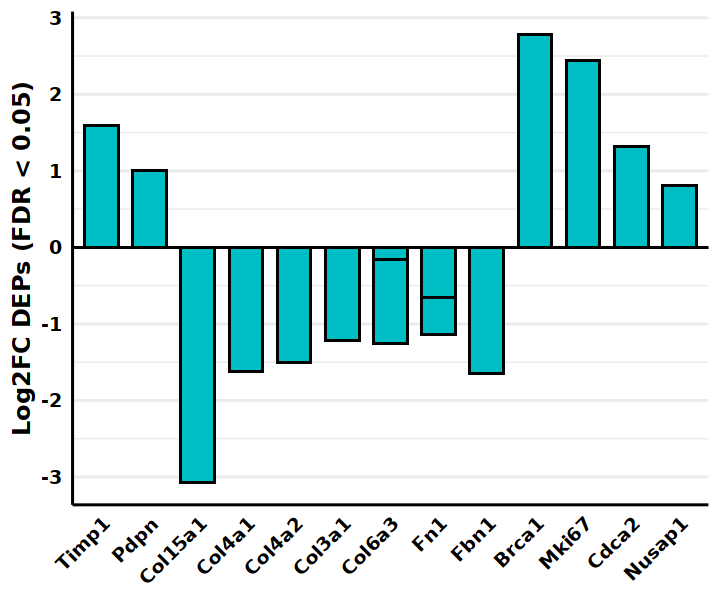

In [4]:
options(repr.plot.width = 6, repr.plot.height = 5)

# Genes to plot (ordered left-to-right as in figure d)
genes_to_plot <- c(
    'Timp1', 'Pdpn', 'Col15a1', 'Col4a1', 'Col4a2', 'Col3a1', 'Col6a3',
    'Fn1', 'Fbn1', 'Brca1', 'Mki67', 'Cdca2', 'Nusap1'
)

plot_df <- proteomics_all %>%
    mutate(gene_symbol = str_extract(identifier, '^[^~]+')) %>%
    filter(gene_symbol %in% genes_to_plot) %>%
    mutate(
        log2FC      = log2(Fold.change),
        gene_symbol = factor(gene_symbol, levels = genes_to_plot)
    )

missing_genes <- setdiff(genes_to_plot, plot_df$gene_symbol)
if (length(missing_genes) > 0) {
    warning('Genes not found in proteomics table: ',
            paste(missing_genes, collapse = ', '))
}

p_d <- ggplot(plot_df, aes(x = gene_symbol, y = log2FC)) +
    geom_bar(stat = 'identity', fill = '#00BFC4', color = 'black', width = 0.7) +
    geom_hline(yintercept = 0, color = 'black') +
    labs(y = 'Log2FC DEPs (FDR < 0.05)', x = NULL, fill = NULL) +
    theme_minimal(base_size = 14) +
    theme(
        axis.text.x          = element_text(angle = 45, hjust = 1, face = 'bold', colour = 'black'),
        axis.text.y          = element_text(face = 'bold', colour = 'black'),
        axis.title.y         = element_text(face = 'bold'),
        legend.position      = 'top',
        panel.grid.major.x   = element_blank(),
        panel.grid.minor.x   = element_blank(),
        axis.line            = element_line(colour = 'black')
    )
p_d

ggsave(file.path(out_dir, 'fig9d_proteomics_log2fc_bars.svg'),
       plot = p_d, width = 6, height = 5, device = 'svg')
write.csv(plot_df, file.path(out_dir, 'fig9d_source_data.csv'), row.names = FALSE)

## GO dotplot helper (panels k, l)

Top-20 terms by adjusted p-value. Dot size = `Count`, colour = `-log10(p.adjust)` on a
blue→red gradient with configurable limits (the up- and down-regulated terms have very
different significance ranges, so each panel gets its own colour scale).

In [5]:
make_custom_dotplot <- function(enrich_df, title, color_limits = c(0, 10)) {
    enrich_df %>%
        arrange(p.adjust) %>%
        slice_head(n = 20) %>%
        mutate(
            GeneRatio       = sapply(strsplit(as.character(GeneRatio), '/'),
                                     function(x) as.numeric(x[1]) / as.numeric(x[2])),
            neg_log10_padj  = -log10(p.adjust),
            Description     = fct_reorder(Description, GeneRatio)
        ) %>%
        ggplot(aes(x = GeneRatio, y = Description)) +
            geom_point(aes(size = Count, color = neg_log10_padj)) +
            scale_size(range = c(3, 10)) +
            scale_color_gradient(
                low    = 'blue', high = 'red',
                limits = color_limits,
                name   = '-log10(p.adj)'
            ) +
            labs(title = title, x = 'GeneRatio', y = NULL) +
            theme_minimal(base_size = 16) +
            theme(
                legend.position  = 'top',
                plot.title       = element_text(hjust = 0, face = 'plain', size = 14),
                axis.text.y      = element_text(face = 'bold', size = 12, colour = 'black'),
                axis.text.x      = element_text(face = 'bold', size = 14, colour = 'black')
            ) +
            guides(
                size  = guide_legend(order = 1),
                color = guide_colorbar(order = 2)
            )
}

## Panel k — Downregulated GO terms in SQ-FL

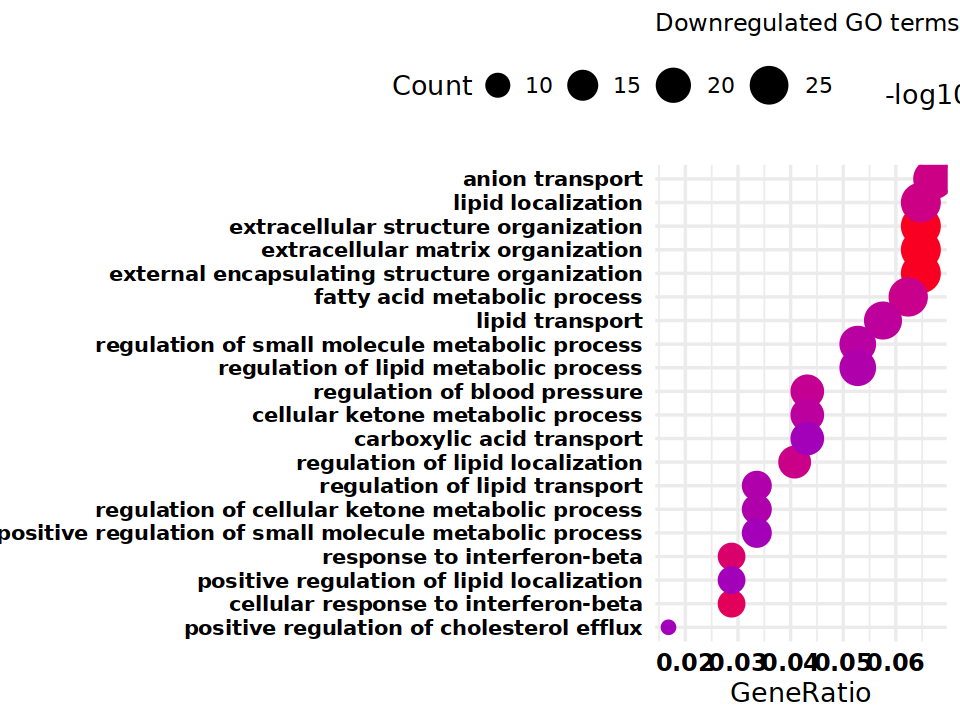

In [6]:
options(repr.plot.width = 8, repr.plot.height = 6)

dot_down <- make_custom_dotplot(
    as.data.frame(ego_down),
    title        = 'Downregulated GO terms in SQ-FL',
    color_limits = c(2, 10)
)
dot_down

ggsave(file.path(out_dir, 'fig9k_dotplot_down_GO.svg'),
       plot = dot_down, width = 8, height = 6, device = 'svg')

## Panel l — Upregulated GO terms in SQ-FL

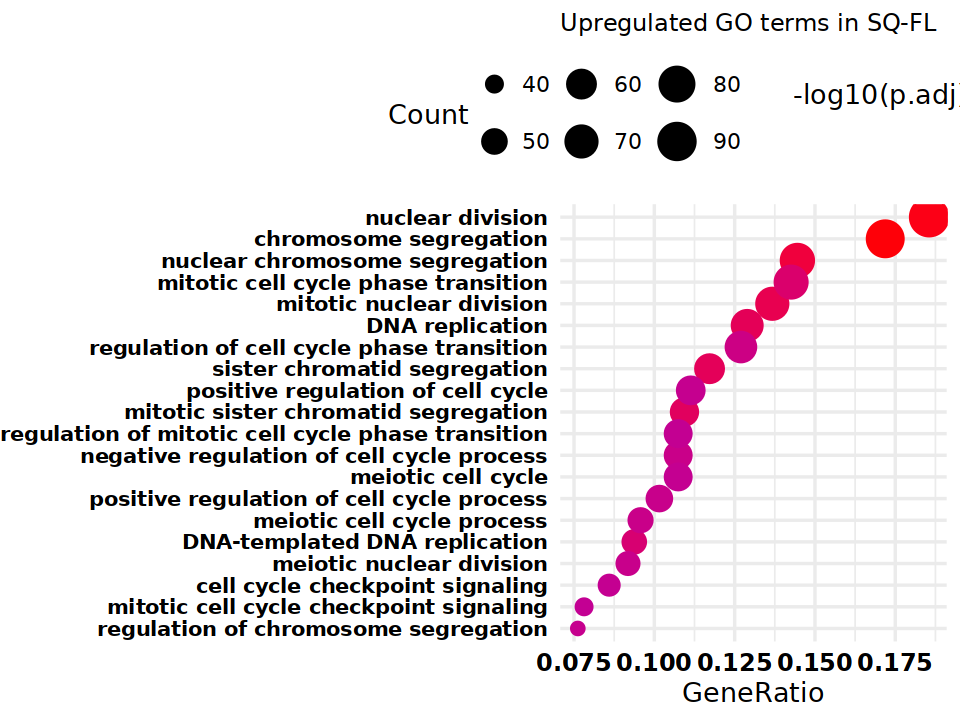

In [7]:
options(repr.plot.width = 8, repr.plot.height = 6)

dot_up <- make_custom_dotplot(
    as.data.frame(ego_up),
    title        = 'Upregulated GO terms in SQ-FL',
    color_limits = c(2, 70)
)
dot_up

ggsave(file.path(out_dir, 'fig9l_dotplot_up_GO.svg'),
       plot = dot_up, width = 8, height = 6, device = 'svg')